<a href="https://colab.research.google.com/github/bugsotim/INTERNSHIP_CN_2026/blob/main/Gap_Analyst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
# List the contents of your Google Drive
# You might need to adjust the path if your data is in a specific subfolder
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['บัตรประชาชน(สำเนา).pdf', 'Classroom', 'แบบฝึกหัดบทที่ 1 เวกเตอร์.pdf', 'แบบฝึกหัดบทที่ 1 เวกเตอร์-6.jpg', 'IMG_2568.jpeg', 'IMG_2569.jpeg', 'แบบฝึกหัดบทที่ 2 แรงและการเคลื่อนที่.pdf', 'quiz 2-236.jpg', 'Quiz 3.pdf', 'สำเนาปชช .pdf', 'IMG_2669.jpeg', 'IMG_2927.png', 'แบบฝึกหัดบทที่ 3 งาน พลังงาน และโมเมนตัม.pdf', 'quiz Phy.pdf', 'Homework I.pdf', 'bio hwll.pdf', '663020585-6.pdf', 'GE Untitled ', 'IMG_3605.jpeg', 'Project Eng', 'Eng บ้านอร่อย', '4020 MNN DOC 10-Oct 2566.xls', 'การบ้านภาวะของสิ่งมีชีวิต 663020040-8 และ 663020585-6.pdf', 'LAB1-ศิริวรรณ-นวลวัน-663020585-6 (1).pdf', 'LAB1-ศิริวรรณ-นวลวัน-663020585-6.pdf', 'LAB2-ศิริวรรณ-นวลวัน-663020585-6.pdf', 'Work1- ศิริวรรณ-นวลวัน_663020585-6.pdf', 'Work2-Prob.pdf', 'Meeting Reports', 'GE321415 t2y2566 sec02 (SC-SI) group-all [AI-BlockChain-Cloud-BigData] 2024-01-15 1300-1600.pptx', 'Work3a-RV-X.pdf', 'Work3b-การแจกแจงของ RV .pdf', 'GE321415_t2y2566_sec02_work06_group00 (SC-SI) 2024-01-30 1300-1600.gdoc', 'GE

In [4]:
file_path = '/content/drive/MyDrive/intern CHN/merged_shopee_data_Final.xlsx'
file_path2 = '/content/drive/MyDrive/intern CHN/hh_data.xlsx'

In [5]:
merged = pd.read_excel(file_path)
hh = pd.read_excel(file_path2)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Update package lists and install thai-fonts
!apt-get update -qq
!apt-get install -y fonts-thai-tlwg -qq

# Clear matplotlib's font cache
# The correct way to clear the cache is often to delete the cache file or rebuild via system calls.
# For Colab, often re-running the cell or relying on findSystemFonts/addfont is sufficient.
# fm.fontManager.clear() # Removed as it causes AttributeError

# Find a Thai font that was just installed
# Common Thai fonts are 'Sarabun' or 'TH Sarabun New' or those from tlwg.
# Searching through common font directories
font_dirs = ['/usr/share/fonts/truetype/thai/', '/usr/share/fonts/truetype/liberation/', '/usr/share/fonts/truetype/THSarabunNew/', '/usr/share/fonts/truetype/tlwg/'] # Added common path for tlwg fonts
font_files = fm.findSystemFonts(fontpaths=font_dirs)

thai_font_path = None
# Prioritize TH Sarabun New or other Sarabun fonts if available
for font_file in font_files:
    if 'THSarabunNew.ttf' in font_file or 'Sarabun' in font_file or 'Laksaman.ttf' in font_file: # Added Laksaman as a common tlwg font
        thai_font_path = font_file
        break

if thai_font_path:
    print(f"Found Thai font: {thai_font_path}")
    # Add font to matplotlib font manager (though findSystemFonts already registers them)
    fm.fontManager.addfont(thai_font_path)

    # Set default font to the Thai font
    plt.rcParams['font.family'] = fm.FontProperties(fname=thai_font_path).get_name()
    plt.rcParams['axes.unicode_minus'] = False # Ensure minus signs are displayed correctly
    print(f"Matplotlib default font set to: {plt.rcParams['font.family']}")
else:
    print("Warning: No suitable Thai font found. Plot text might not display correctly.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-tlwg-garuda-ttf.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../00-fonts-tlwg-garuda-ttf_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-garuda-ttf (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-garuda.
Preparing to unpack .../01-fonts-tlwg-garuda_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-garuda (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-kinnari-ttf.
Preparing to unpack .../02-fonts-tlwg-kinnari-ttf_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-kinnari-ttf (1:0.7.3-1) ...
Selecting previously unselected package fonts-tlwg-kinnari.
Preparing to unpack .../03-fonts-tlwg-kinnari_1%3a0.7.3-1_all.deb ...
Unpacking fonts-tlwg-kinnari (1:0.7.3-1) ...
Selecting previously

In [7]:
unique_orders = merged.drop_duplicates(subset=['หมายเลขคำสั่งซื้อ'])

In [8]:
unique_orders['เวลาที่ทำการสั่งซื้อสำเร็จ'] = pd.to_datetime(unique_orders['เวลาที่ทำการสั่งซื้อสำเร็จ'])

# Calculate duration for 'เก็บเงินปลายทาง' transactions
cod_mask = unique_orders['ช่องทางการชำระเงิน'] == 'เก็บเงินปลายทาง'
unique_orders.loc[cod_mask, 'duration'] = unique_orders.loc[cod_mask, 'เวลาที่ทำการสั่งซื้อสำเร็จ'] - unique_orders.loc[cod_mask, 'วันที่ทำการสั่งซื้อ']

# Calculate duration for other payment methods
other_mask = unique_orders['ช่องทางการชำระเงิน'] != 'เก็บเงินปลายทาง'
unique_orders.loc[other_mask, 'duration'] = unique_orders.loc[other_mask, 'เวลาการชำระสินค้า'] - unique_orders.loc[other_mask, 'วันที่ทำการสั่งซื้อ']

display(unique_orders.head())
unique_orders = unique_orders.drop(columns=['Duration'])

/tmp/ipykernel_6023/3827473932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_orders['เวลาที่ทำการสั่งซื้อสำเร็จ'] = pd.to_datetime(unique_orders['เวลาที่ทำการสั่งซื้อสำเร็จ'])
/tmp/ipykernel_6023/3827473932.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_orders.loc[cod_mask, 'duration'] = unique_orders.loc[cod_mask, 'เวลาที่ทำการสั่งซื้อสำเร็จ'] - unique_orders.loc[cod_mask, 'วันที่ทำการสั่งซื้อ']


,หมายเลขคำสั่งซื้อ,สถานะการคืนเงินหรือคืนสินค้า,วันที่ทำการสั่งซื้อ,เวลาการชำระสินค้า,ช่องทางการชำระเงิน,ช่องทางการชำระเงิน_(รายละเอียด),แผนการผ่อนชำระ,ค่าธรรมเนียม_(%),ตัวเลือกการจัดส่ง,*หมายเลขติดตามพัสดุ,...,เขต/อำเภอ,เวลาที่ทำการสั่งซื้อสำเร็จ,Mecanic_cam,group,ยอดขายรวม,ส่วนลดรวม,ราคาลูกค้าจ่าย,Disรวม%,Duration,duration
0,240103UWX9N588,NaN,2024-01-03 12:44:00,2024-01-03 12:44:00,Mobile Banking,NaN,iBanking Payment V2 (SCB),3.21%,Standard Delivery - ส่งธรรมดาในประเทศ-J&T Express,624451474253,...,อำเภอบางพลี,2024-01-04 18:17:00,Normal,old,689,0,689,0.000000,0.000000,0 days 00:00:00
2,240103THAPRG1G,NaN,2024-01-02 23:26:00,2024-01-02 23:26:00,บัตรเครดิต/บัตรเดบิต,NaN,Airpay Credit Card,3.21%,Standard Delivery - ส่งธรรมดาในประเทศ-J&T Express,628281250111,...,เขตจตุจักร,2024-01-04 22:32:00,Normal,old,350,35,315,10.000000,0.000000,0 days 00:00:00
4,240102SRPHXTVH,NaN,2024-01-02 16:05:00,2024-01-02 16:35:00,เก็บเงินปลายทาง,NaN,Cash on Delivery,3.21%,Standard Delivery - ส่งธรรมดาในประเทศ-J&T Express,624257659830,...,อำเภอชุมแพ,2024-01-05 00:22:00,Normal,old,380,100,280,26.315789,0.020833,2 days 08:17:00
5,240102TCV8869T,NaN,2024-01-02 22:06:00,2024-01-02 22:36:00,เก็บเงินปลายทาง,NaN,Cash on Delivery,3.21%,Standard Delivery - ส่งธรรมดาในประเทศ-J&T Express,622282967460,...,อำเภอท่าม่วง,2024-01-05 16:09:00,Normal,old,175,53,122,30.285714,0.020833,2 days 18:03:00
6,2401040WQKYE7R,NaN,2024-01-04 08:45:00,2024-01-04 08:45:00,SPayLater,Shopee Credit Down Payment,Shopee Credit x3,3.21%,Standard Delivery - ส่งธรรมดาในประเทศ-J&T Express,629807971461,...,อำเภออุบลรัตน์,2024-01-05 16:41:00,Normal,old,380,0,380,0.000000,0.000000,0 days 00:00:00


In [9]:
hh = unique_orders[unique_orders['ช่องทางการชำระเงิน'] != 'เก็บเงินปลายทาง']

In [10]:
import pandas as pd

summary = (
    unique_orders.groupby('ช่องทางการชำระเงิน')['duration']
    .agg(['mean', 'max', 'min'])
    .reset_index()
)

# แปลง timedelta เป็น HH:MM:SS
for col in ['mean', 'max', 'min']:
    summary[col] = summary[col].astype(str).str.split('.').str[0]

summary.columns = ['Payment Method', 'Mean', 'Max', 'Min']

print(summary)

               Payment Method             Mean               Max  \
0                  Google Pay  0 days 00:01:00   0 days 00:01:00   
1              Mobile Banking  0 days 00:19:45   0 days 23:59:00   
2                QR พร้อมเพย์  0 days 01:08:13   1 days 00:00:00   
3                   SPayLater  0 days 00:10:10   0 days 23:54:00   
4  ShopeePay - ตัดบัญชีธนาคาร  0 days 00:16:26   0 days 23:59:00   
5             คะแนนบัตรเครดิต  0 days 00:00:00   0 days 00:00:00   
6        บัตรเครดิต/บัตรเดบิต  0 days 00:15:45   0 days 23:48:00   
7           ยอดเงิน ShopeePay  0 days 00:14:45   0 days 23:34:00   
8             เก็บเงินปลายทาง  9 days 07:59:17  26 days 13:12:00   
9             ไม่ต้องชำระเงิน  0 days 00:00:00   0 days 00:00:00   

               Min  
0  0 days 00:01:00  
1  0 days 00:00:00  
2  0 days 00:00:00  
3  0 days 00:00:00  
4  0 days 00:00:00  
5  0 days 00:00:00  
6  0 days 00:00:00  
7  0 days 00:00:00  
8  0 days 01:23:00  
9  0 days 00:00:00  


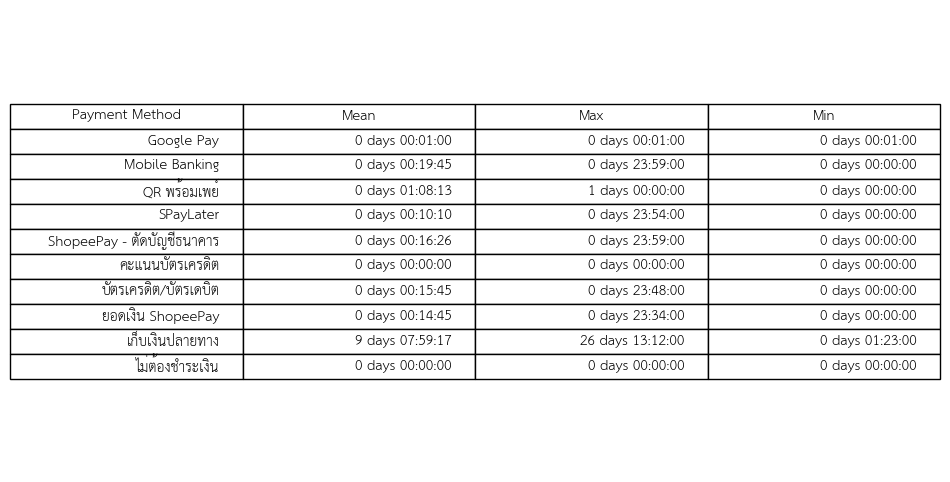

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
ax.axis('off')

table = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()

✅ พบ Thai font ในระบบ: Laksaman  (/usr/share/fonts/truetype/tlwg/Laksaman-BoldItalic.ttf)

📊 Mean Duration (ชั่วโมง) — เรียงจากช้าไปเร็ว:
            Payment Method  Mean (hr)  Max (hr)  Min (hr)  Range (hr)
           เก็บเงินปลายทาง     223.99    637.20      1.38      635.82
              QR พร้อมเพย์       1.14     24.00      0.00       24.00
            Mobile Banking       0.33     23.98      0.00       23.98
ShopeePay - ตัดบัญชีธนาคาร       0.27     23.98      0.00       23.98
      บัตรเครดิต/บัตรเดบิต       0.26     23.80      0.00       23.80
         ยอดเงิน ShopeePay       0.25     23.57      0.00       23.57
                 SPayLater       0.17     23.90      0.00       23.90
                Google Pay       0.02      0.02      0.02        0.00
           คะแนนบัตรเครดิต       0.00      0.00      0.00        0.00
           ไม่ต้องชำระเงิน       0.00      0.00      0.00        0.00


(0.0, 1.4213922138888888)

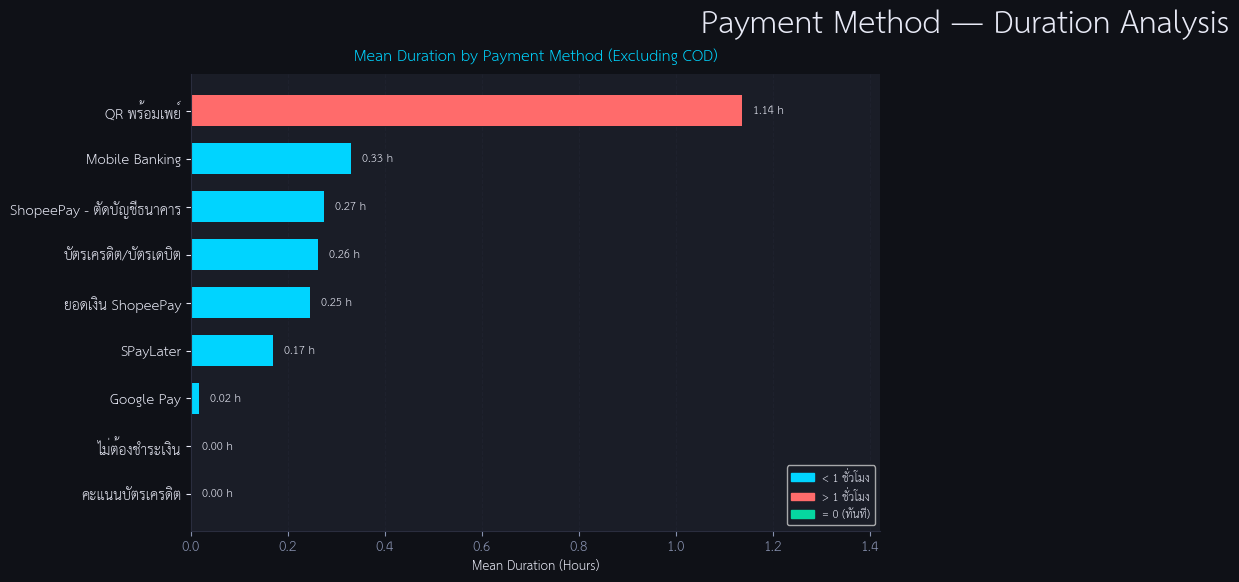

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
import urllib.request
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 0. THAI FONT SETUP
# ============================================================

def setup_thai_font():
    """
    ติดตั้ง font ภาษาไทย (Sarabun) สำหรับ matplotlib
    รองรับ Colab / Jupyter / Local Python
    """
    import os

    # 1) ลองหา font ที่ติดตั้งไว้แล้วในระบบ (apt-get install fonts-thai-tlwg)
    search_dirs = [
        "/usr/share/fonts/truetype/thai/",
        "/usr/share/fonts/truetype/tlwg/",
        "/usr/share/fonts/truetype/THSarabunNew/",
    ]
    for d in search_dirs:
        for f in fm.findSystemFonts(fontpaths=[d]):
            lower = f.lower()
            if any(k in lower for k in ["sarabun", "laksaman", "thsarabun"]):
                fm.fontManager.addfont(f)
                name = fm.FontProperties(fname=f).get_name()
                print(f"✅ พบ Thai font ในระบบ: {name}  ({f})")
                return name

    # 2) ถ้าไม่มี → download Sarabun-Regular จาก Google Fonts (GitHub)
    url   = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
    path  = "/tmp/Sarabun-Regular.ttf"
    if not os.path.exists(path):
        print("⬇️  ดาวน์โหลด Sarabun-Regular.ttf …")
        urllib.request.urlretrieve(url, path)
    fm.fontManager.addfont(path)
    name = fm.FontProperties(fname=path).get_name()
    print(f"✅ โหลด Thai font สำเร็จ: {name}")
    return name

THAI_FONT = setup_thai_font()

plt.rcParams.update({
    "font.family"        : THAI_FONT,
    "axes.unicode_minus" : False,
})

# ============================================================
# 1. DATA SETUP
# ============================================================

def parse_duration(s):
    """แปลง '0 days 00:19:45.466321243' → วินาที (float)"""
    if pd.isna(s) or str(s).strip() == "":
        return 0.0
    try:
        return pd.Timedelta(str(s).strip()).total_seconds()
    except Exception:
        return 0.0

raw_data = {
    "Payment Method": [
        "Google Pay",
        "Mobile Banking",
        "QR พร้อมเพย์",
        "SPayLater",
        "ShopeePay - ตัดบัญชีธนาคาร",
        "คะแนนบัตรเครดิต",
        "บัตรเครดิต/บัตรเดบิต",
        "ยอดเงิน ShopeePay",
        "เก็บเงินปลายทาง",
        "ไม่ต้องชำระเงิน",
    ],
    "Mean Duration": [
        "0 days 00:01:00",
        "0 days 00:19:45.466321243",
        "0 days 01:08:13.609576427",
        "0 days 00:10:10.039194485",
        "0 days 00:16:26.144376049",
        "0 days 00:00:00",
        "0 days 00:15:45.092150170",
        "0 days 00:14:45.047923322",
        "9 days 07:59:17.174455166",
        "0 days 00:00:00",
    ],
    "Max Duration": [
        "0 days 00:01:00",
        "0 days 23:59:00",
        "1 days 00:00:00",
        "0 days 23:54:00",
        "0 days 23:59:00",
        "0 days 00:00:00",
        "0 days 23:48:00",
        "0 days 23:34:00",
        "26 days 13:12:00",
        "0 days 00:00:00",
    ],
    "Min Duration": [
        "0 days 00:01:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 01:23:00",
        "0 days 00:00:00",
    ],
}

df = pd.DataFrame(raw_data)
for col in ["Mean Duration", "Max Duration", "Min Duration"]:
    df[col + "_sec"] = df[col].apply(parse_duration)

df["Mean_hr"]  = df["Mean Duration_sec"] / 3600
df["Max_hr"]   = df["Max Duration_sec"] / 3600
df["Min_hr"]   = df["Min Duration_sec"] / 3600
df["Range_hr"] = df["Max_hr"] - df["Min_hr"]

# ============================================================
# 2. BASIC STATS
# ============================================================

print("\n📊 Mean Duration (ชั่วโมง) — เรียงจากช้าไปเร็ว:")
summary = (
    df[["Payment Method", "Mean_hr", "Max_hr", "Min_hr", "Range_hr"]]
    .sort_values("Mean_hr", ascending=False)
    .copy()
)
summary.columns = ["Payment Method", "Mean (hr)", "Max (hr)", "Min (hr)", "Range (hr)"]
print(summary.to_string(index=False, float_format="{:.2f}".format))

# ============================================================
# 3. VISUALISATION
# ============================================================

COLORS = {
    "bg"      : "#0f1117",
    "panel"   : "#1a1d27",
    "accent1" : "#00d4ff",
    "accent2" : "#ff6b6b",
    "accent3" : "#ffd166",
    "accent4" : "#06d6a0",
    "text"    : "#e8eaf6",
    "subtext" : "#8892b0",
    "grid"    : "#2a2d3e",
}

plt.rcParams.update({
    "axes.facecolor"  : COLORS["panel"],
    "figure.facecolor": COLORS["bg"],
    "text.color"      : COLORS["text"],
    "axes.labelcolor" : COLORS["text"],
    "xtick.color"     : COLORS["subtext"],
    "ytick.color"     : COLORS["text"],
    "axes.edgecolor"  : COLORS["grid"],
    "grid.color"      : COLORS["grid"],
    "grid.alpha"      : 0.5,
})

fig = plt.figure(figsize=(18, 13), facecolor=COLORS["bg"])
fig.suptitle(
    "Payment Method — Duration Analysis",
    fontsize=22, fontweight="bold", color=COLORS["text"], y=0.97,
)

gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35,
              left=0.07, right=0.97, top=0.92, bottom=0.06)

def label_bars(ax, bars, fmt="{:.1f}", suffix=""):
    for bar in bars:
        h = bar.get_height()
        if h > 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 0.5,
                fmt.format(h) + suffix,
                ha="center", va="bottom", fontsize=7.5, color=COLORS["text"],
            )

# ========= Mean Duration by Payment Method (Exclude COD) =========

ax1 = fig.add_subplot(gs[0, 0])

# เตรียมข้อมูล
df_no_cod = (
    df[df["Payment Method"] != "เก็บเงินปลายทาง"]
    .copy()
    .sort_values("Mean_hr", ascending=True)
)

# กำหนดสี
bar_colors = [
    COLORS["accent4"] if v == 0 else
    COLORS["accent2"] if v > 1 else
    COLORS["accent1"]
    for v in df_no_cod["Mean_hr"]
]

# วาดกราฟ
bars = ax1.barh(
    y=df_no_cod["Payment Method"],
    width=df_no_cod["Mean_hr"],
    color=bar_colors,
    edgecolor="none",
    height=0.65
)

# แสดงค่าที่ปลายแท่ง
for bar in bars:
    width = bar.get_width()

    ax1.text(
        width + (df_no_cod["Mean_hr"].max() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f} h",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

# ตกแต่งกราฟ
ax1.set_title(
    "Mean Duration by Payment Method (Excluding COD)",
    fontsize=11,
    fontweight="bold",
    color=COLORS["accent1"],
    pad=10
)

ax1.set_xlabel("Mean Duration (Hours)", fontsize=9)
ax1.set_ylabel("")

ax1.grid(axis="x", linestyle="--", alpha=0.3)
ax1.set_axisbelow(True)

# Legend
ax1.legend(
    handles=[
        mpatches.Patch(color=COLORS["accent1"], label="< 1 ชั่วโมง"),
        mpatches.Patch(color=COLORS["accent2"], label="> 1 ชั่วโมง"),
        mpatches.Patch(color=COLORS["accent4"], label="= 0 (ทันที)")
    ],
    fontsize=8,
    loc="lower right",
    frameon=True
)

# ลบเส้นกรอบบน-ขวา
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# เพิ่มพื้นที่ด้านขวาให้ตัวเลขไม่ล้น
ax1.set_xlim(
    0,
    df_no_cod["Mean_hr"].max() * 1.25
)

✅ พบ Thai font ในระบบ: Laksaman  (/usr/share/fonts/truetype/tlwg/Laksaman-BoldItalic.ttf)


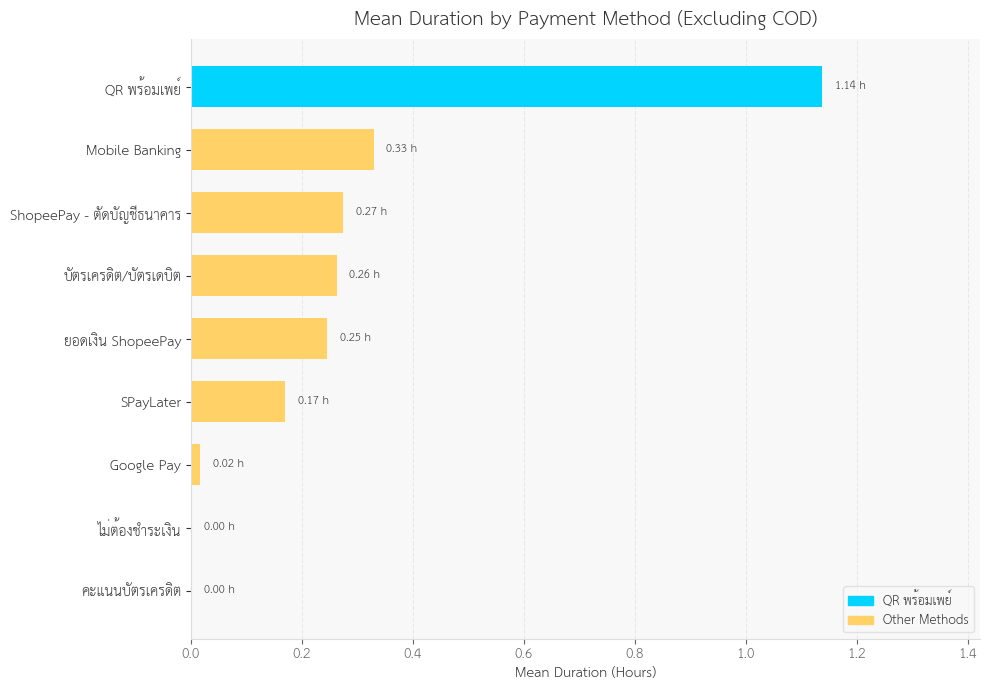

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import urllib.request
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 0. THAI FONT SETUP
# ============================================================

def setup_thai_font():
    """
    ติดตั้ง font ภาษาไทย (Sarabun) สำหรับ matplotlib
    รองรับ Colab / Jupyter / Local Python
    """
    import os

    # 1) ลองหา font ที่ติดตั้งไว้แล้วในระบบ (apt-get install fonts-thai-tlwg)
    search_dirs = [
        "/usr/share/fonts/truetype/thai/",
        "/usr/share/fonts/truetype/tlwg/",
        "/usr/share/fonts/truetype/THSarabunNew/",
    ]
    for d in search_dirs:
        for f in fm.findSystemFonts(fontpaths=[d]):
            lower = f.lower()
            if any(k in lower for k in ["sarabun", "laksaman", "thsarabun"]):
                fm.fontManager.addfont(f)
                name = fm.FontProperties(fname=f).get_name()
                print(f"✅ พบ Thai font ในระบบ: {name}  ({f})")
                return name

    # 2) ถ้าไม่มี → download Sarabun-Regular จาก Google Fonts (GitHub)
    url   = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
    path  = "/tmp/Sarabun-Regular.ttf"
    if not os.path.exists(path):
        print("⬇️  ดาวน์โหลด Sarabun-Regular.ttf …")
        urllib.request.urlretrieve(url, path)
    fm.fontManager.addfont(path)
    name = fm.FontProperties(fname=path).get_name()
    print(f"✅ โหลด Thai font สำเร็จ: {name}")
    return name

THAI_FONT = setup_thai_font()

plt.rcParams.update({
    "font.family"        : THAI_FONT,
    "axes.unicode_minus" : False,
})

# ============================================================
# 1. DATA SETUP
# ============================================================

def parse_duration(s):
    """แปลง '0 days 00:19:45.466321243' → วินาที (float)"""
    if pd.isna(s) or str(s).strip() == "":
        return 0.0
    try:
        return pd.Timedelta(str(s).strip()).total_seconds()
    except Exception:
        return 0.0

raw_data = {
    "Payment Method": [
        "Google Pay",
        "Mobile Banking",
        "QR พร้อมเพย์",
        "SPayLater",
        "ShopeePay - ตัดบัญชีธนาคาร",
        "คะแนนบัตรเครดิต",
        "บัตรเครดิต/บัตรเดบิต",
        "ยอดเงิน ShopeePay",
        "เก็บเงินปลายทาง",
        "ไม่ต้องชำระเงิน",
    ],
    "Mean Duration": [
        "0 days 00:01:00",
        "0 days 00:19:45.466321243",
        "0 days 01:08:13.609576427",
        "0 days 00:10:10.039194485",
        "0 days 00:16:26.144376049",
        "0 days 00:00:00",
        "0 days 00:15:45.092150170",
        "0 days 00:14:45.047923322",
        "9 days 07:59:17.174455166",
        "0 days 00:00:00",
    ],
    "Max Duration": [
        "0 days 00:01:00",
        "0 days 23:59:00",
        "1 days 00:00:00",
        "0 days 23:54:00",
        "0 days 23:59:00",
        "0 days 00:00:00",
        "0 days 23:48:00",
        "0 days 23:34:00",
        "26 days 13:12:00",
        "0 days 00:00:00",
    ],
    "Min Duration": [
        "0 days 00:01:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 00:00:00",
        "0 days 01:23:00",
        "0 days 00:00:00",
    ],
}

df = pd.DataFrame(raw_data)
for col in ["Mean Duration", "Max Duration", "Min Duration"]:
    df[col + "_sec"] = df[col].apply(parse_duration)

df["Mean_hr"]  = df["Mean Duration_sec"] / 3600
df["Max_hr"]   = df["Max Duration_sec"] / 3600
df["Min_hr"]   = df["Min Duration_sec"] / 3600
df["Range_hr"] = df["Max_hr"] - df["Min_hr"]

# ============================================================
# 2. VISUALISATION
# ============================================================

COLORS = {
    "bg"      : "#FFFFFF", # Changed to white
    "panel"   : "#F8F8F8", # Changed to light gray
    "accent1" : "#00d4ff",
    "accent2" : "#ff6b6b",
    "accent3" : "#ffd166", # Gold
    "accent4" : "#06d6a0",
    "text"    : "#333333", # Dark grey for readability
    "subtext" : "#666666", # Medium grey
    "grid"    : "#DDDDDD", # Light grey for grid
}

plt.rcParams.update({
    "axes.facecolor"  : COLORS["panel"],
    "figure.facecolor": COLORS["bg"],
    "text.color"      : COLORS["text"],
    "axes.labelcolor" : COLORS["text"],
    "xtick.color"     : COLORS["subtext"],
    "ytick.color"     : COLORS["text"],
    "axes.edgecolor"  : COLORS["grid"],
    "grid.color"      : COLORS["grid"],
    "grid.alpha"      : 0.8, # Increased grid visibility on light background
})

fig, ax1 = plt.subplots(figsize=(10, 7), facecolor=COLORS["bg"])

# Prepare data
df_no_cod = (
    df[df["Payment Method"] != "เก็บเงินปลายทาง"]
    .copy()
    .sort_values("Mean_hr", ascending=True)
)

# Define colors based on user request
bar_colors = []
for _, row in df_no_cod.iterrows():
    if row["Payment Method"] == "QR พร้อมเพย์":
        bar_colors.append(COLORS["accent1"]) # Blue for QR พร้อมเพย์
    else:
        bar_colors.append(COLORS["accent3"]) # Gold for all others

# Plot bar chart
bars = ax1.barh(
    y=df_no_cod["Payment Method"],
    width=df_no_cod["Mean_hr"],
    color=bar_colors,
    edgecolor="none",
    height=0.65
)

# Add values at the end of bars
for bar in bars:
    width = bar.get_width()
    ax1.text(
        width + (df_no_cod["Mean_hr"].max() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f} h",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold",
        color=COLORS["text"]
    )

# Customize plot
ax1.set_title(
    "Mean Duration by Payment Method (Excluding COD)",
    fontsize=14,
    fontweight="bold",
    color=COLORS["text"], # Changed to dark text color
    pad=10
)

ax1.set_xlabel("Mean Duration (Hours)", fontsize=10, color=COLORS["text"])
ax1.set_ylabel("", color=COLORS["text"])

ax1.grid(axis="x", linestyle="--", alpha=0.6) # Adjusted grid alpha
ax1.set_axisbelow(True)

# Legend - Updated to reflect new color scheme
ax1.legend(
    handles=[
        mpatches.Patch(color=COLORS["accent1"], label="QR พร้อมเพย์"),
        mpatches.Patch(color=COLORS["accent3"], label="Other Methods")
    ],
    fontsize=9,
    loc="lower right",
    frameon=True,
    facecolor=COLORS["panel"],
    edgecolor=COLORS["grid"]
)

# Remove top and right spines
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(COLORS["grid"])
ax1.spines["bottom"].set_color(COLORS["grid"])

# Adjust x-axis limits to prevent text overflow
ax1.set_xlim(
    0,
    df_no_cod["Mean_hr"].max() * 1.25
)

plt.tight_layout()
plt.show()


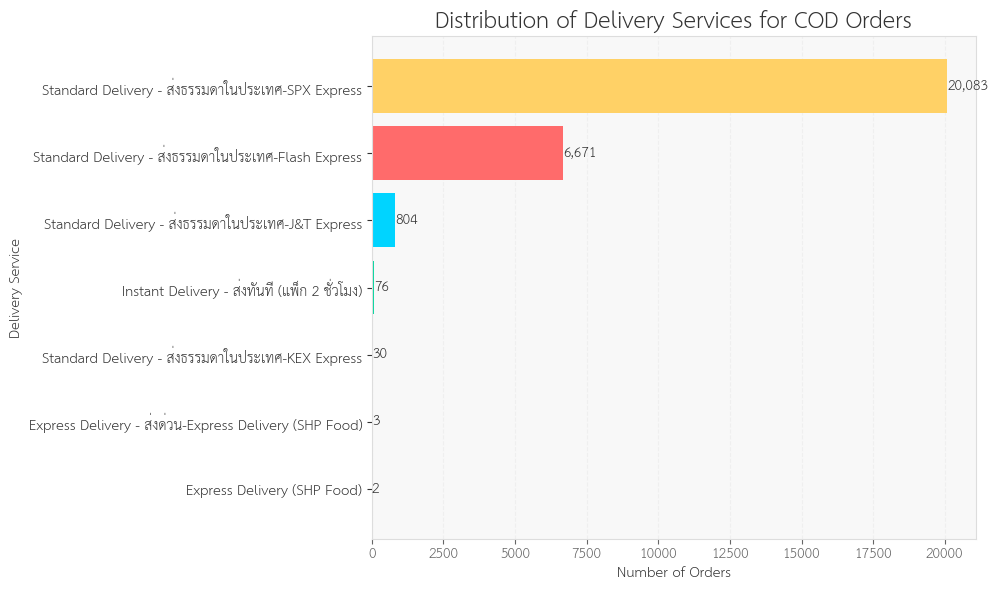

In [14]:
if 'unique_orders' in locals() and not unique_orders.empty:

    cod_orders = unique_orders[
        unique_orders['ช่องทางการชำระเงิน'] == 'เก็บเงินปลายทาง'
    ]

    if not cod_orders.empty:

        delivery_service_counts = (
            cod_orders['ตัวเลือกการจัดส่ง']
            .value_counts()
            .sort_values()
        )

        if not delivery_service_counts.empty:

            # สีตามจำนวนแท่ง
            bar_colors = [
                COLORS['accent1'],
                COLORS['accent2'],
                COLORS['accent3'],
                COLORS['accent4']
            ]

            # ถ้ามีมากกว่า 4 บริษัทให้วนสี
            colors = [
                bar_colors[i % len(bar_colors)]
                for i in range(len(delivery_service_counts))
            ]

            plt.figure(figsize=(10, 6), facecolor=COLORS['bg'])

            bars = plt.barh(
                delivery_service_counts.index,
                delivery_service_counts.values,
                color=colors
            )

            # แสดงจำนวนบนแท่ง
            for bar in bars:
                width = bar.get_width()

                plt.text(
                    width + 0.5,
                    bar.get_y() + bar.get_height()/2,
                    f'{int(width):,}',
                    va='center',
                    fontsize=10,
                    color=COLORS['text']
                )

            plt.title(
                'Distribution of Delivery Services for COD Orders',
                fontsize=16,
                fontweight='bold',
                color=COLORS['text']
            )

            plt.xlabel('Number of Orders')
            plt.ylabel('Delivery Service')

            plt.grid(
                axis='x',
                linestyle='--',
                alpha=0.3
            )

            plt.gca().set_axisbelow(True)

            plt.tight_layout()
            plt.show()

        else:
            print("No delivery service data available for COD orders.")

    else:
        print("No Cash on Delivery (COD) orders found in the data.")

else:
    print("The 'unique_orders' DataFrame is not available or is empty.")

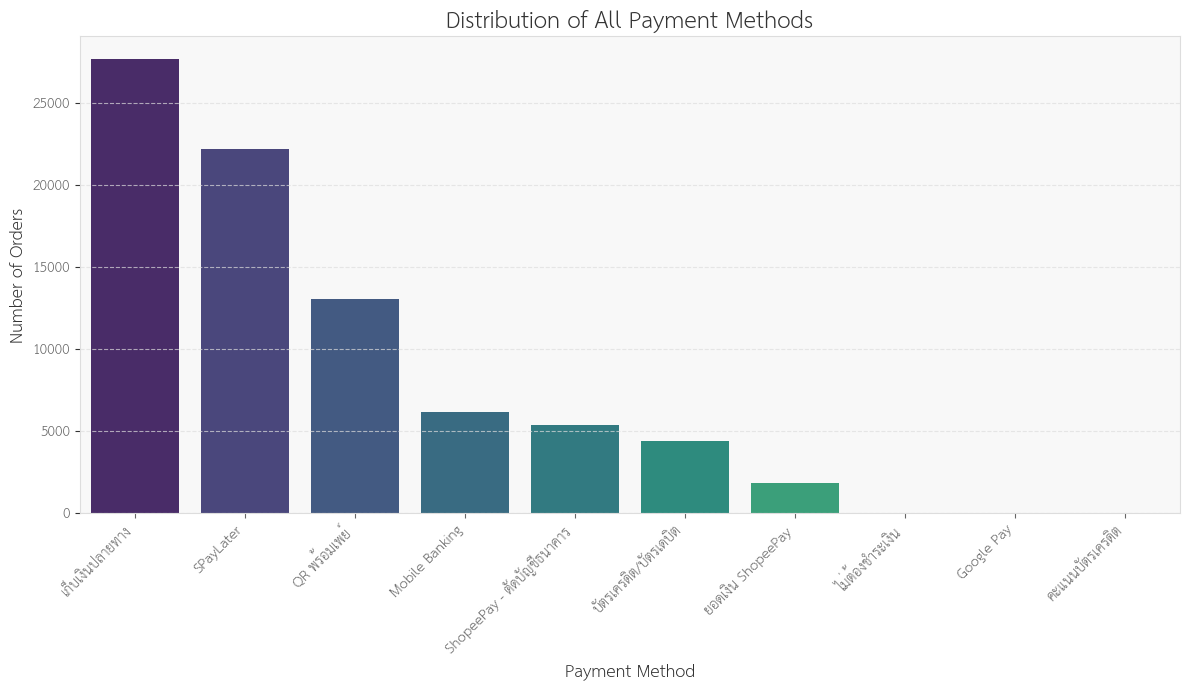

In [15]:
import seaborn as sns

payment_method_counts = unique_orders['ช่องทางการชำระเงิน'].value_counts()

plt.figure(figsize=(12, 7), facecolor=COLORS['bg'])
sns.barplot(x=payment_method_counts.index, y=payment_method_counts.values, palette='viridis')
plt.title('Distribution of All Payment Methods', fontsize=16, fontweight='bold', color=COLORS['text'])
plt.xlabel('Payment Method', fontsize=12, color=COLORS['text'])
plt.ylabel('Number of Orders', fontsize=12, color=COLORS['text'])
plt.xticks(rotation=45, ha='right', fontsize=10, color=COLORS['subtext'])
plt.yticks(fontsize=10, color=COLORS['subtext'])
plt.grid(axis='y', linestyle='--', alpha=0.7, color=COLORS['grid'])
plt.tight_layout()
plt.show()

In [20]:

payment_method_counts = unique_orders['Mecanic_cam'].value_counts()

In [17]:
display(payment_method_counts)

,count
Mecanic_cam,
Normal,79666
Flash Sale,691
Pay Day,175
Double Day,104
Hello 2025,61
Mid Month,18


In [18]:
unique_orders['duration'].max()

Timedelta('26 days 13:12:00')

In [19]:
# Find the row with the maximum duration
longest_duration_order = unique_orders.loc[unique_orders['duration'].idxmax()]

# Extract the Order ID and Delivery Service
order_id = longest_duration_order['หมายเลขคำสั่งซื้อ']
delivery_service = longest_duration_order['ตัวเลือกการจัดส่ง']
duration_value = longest_duration_order['duration']

print(f"Order ID with the longest duration: {order_id}")
print(f"Delivery Service for this order: {delivery_service}")
print(f"Longest duration: {duration_value}")

Order ID with the longest duration: 2501118ME6D7MF
Delivery Service for this order: Standard Delivery - ส่งธรรมดาในประเทศ-SPX Express
Longest duration: 26 days 13:12:00
